# TUTORIAL-I: Introduction to Bfrescox
**Ozge Surer (Northwestern), Filomena Nunes (Michigan State), Matt Plumlee (Northwestern), Stefan Wild (Argonne)**

## Uncertainty quantification

Many scientific applications (like in physics!) use computer models (simulators) to describe physical systems

Challenges for statistics:

How do we make inferences about the world from a simulation of it?
* how do we relate simulators to reality?
* how do we estimate uncertain parameters?
* how do we deal with computational constraints?

$\color{red}{\text{Statistical models need to keep up with these advancements.}}$


* Computer model $\eta: \mathbb{R}^d \rightarrow \mathbb{R}$, that is a function of parameter $\theta$

* Unfortunately, $\theta$ is not known to the experimenters

* All inference must be done using a finite ensemble of model runs $D_{sim} = \{(\theta_i, \eta(\theta_i))\}_{i = 1, \ldots, N}$.

* If $\theta$ is not in the ensemble, then we are uncertain about the value of $\eta(\theta)$, and want to predict output with uncertainty at unobserved inputs.

## Meta-modeling

* If the simulator is expensive, build a cheap model of it and use this in any analysis ($\color{red}{\text{a model of the model}}$)

* We call this a meta-model/surrogate/emulator/reduced-order model of
the simulator $\eta$.

* An emulator should come with an assessment of its accuracy
rather than just predicting $\eta(\theta)$. It should predict $\pi(\eta(\theta)|D_{sim})$ - our uncertainty about the simulator value given the ensemble $D_{sim}$.

* **Emulators** are statistical models of simulation experiments used to generate **predictions with appropriate uncertainty quantification.**

## Gaussian process emulator

Gaussian processes regression models have been
widely used in machine learning applications because of their flexibility and uncertainty measures over predictions.

$\eta(.) \propto GP(m(.), \sigma^2 c(.,.))$

where $m(.)$ is a prior mean function and $c(.,.)$ is a prior covariance function.

If we observe the ensemble of model runs $D_{sim}$, then update our prior belief about $\eta(.)$ in light of the ensemble of model runs:

$\eta(.)|D_{sim} \propto GP(m^*(.), \sigma^2 c^*(.,.))$

where $m^*$ and $c^∗$ are the updated mean and covariance functions.

## Example of a univariate emulation

In [1]:
%%bash

pip install emcee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.6 MB/s eta 0:00:00


In [19]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import numpy as np
from matplotlib import pyplot as plt
import emcee
import seaborn as sns

# simulation function
def eta(theta):
  """The function to predict."""
  return theta * np.sin(theta)

In [20]:
# function to fit an emulator
def fit_emulator(theta, feval):
  kernel = C(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2))
  gp = GaussianProcessRegressor(kernel=kernel, alpha=1, n_restarts_optimizer=10)
  gp.fit(theta, feval)
  return gp

In [21]:
# function to visualize emulation predictions
def vis(theta_test, ftest, theta, feval, dfeval, y_pred, sigma):
  plt.figure()
  plt.plot(theta_test, ftest, "r:", label=r"$\eta(\theta) = \theta\,\sin( \theta )$")
  plt.errorbar(theta.ravel(), feval, dfeval, fmt="r.", markersize=10, label="Observations")
  plt.plot(theta_test, y_pred, "b-", label="Prediction")
  plt.fill(np.concatenate([theta_test, theta_test[::-1]]),
           np.concatenate([y_pred - 1.9600 * sigma, (y_pred + 1.9600 * sigma)[::-1]]),
           alpha=0.5,
           fc="b",
           ec="None",
           label="95% confidence interval",
  )
  plt.xlabel(r"$\theta$")
  plt.ylabel(r"$\eta(\theta)$")
  plt.ylim(-10, 20)
  plt.legend(loc="upper left")
  plt.show()

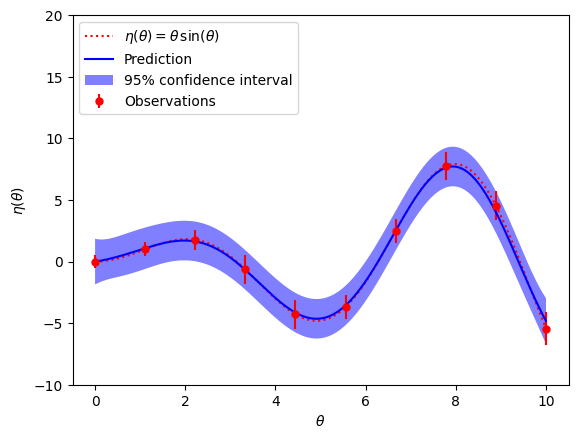

In [23]:
# Create n random theta between 0 and 10, and f(theta)
#### #### #### EXERCISE #### #### #### #### ####
#### Try different sample sizes
#### n = 5, n = 10, n = 15, n = 20, n = 25 ####
#### #### #### EXERCISE #### #### #### #### ####

n = 10
#theta = np.reshape(np.random.random(n)*10, (n, 1))
theta = np.atleast_2d(np.linspace(0, 10, n)).T
feval = eta(theta).ravel()
dfeval = 0.5 + 1.0 * np.random.random(feval.shape)

# Fit a GP emulator
gpr = fit_emulator(theta, feval)

# Make the prediction on the meshed x-axis
theta_test = np.atleast_2d(np.linspace(0, 10, 1000)).T
pred_mean, pred_sigma = gpr.predict(theta_test, return_std=True)
vis(theta_test, eta(theta_test), theta, feval, dfeval, pred_mean, pred_sigma)

## Multivariate emulation

How can we deal with multivariate ouput?

If the outputs are highly correlated we can reduce the dimension
of the data by projecting the data into some lower dimensional space.

### Principal component emulator
* Center and scale the data $D_{sim}$
* Find the singular value decomposition of
  $D_{sim} = U \Gamma V$
  where $\Gamma$ contains the singular values (eigenvalues), $V$ the principal components (eigenvectors)
* Decide on the principal subspace, $q$ say, and throw away all but the $q$ leading principal components. An orthonormal basis for the principal subspace is given by the first $q$ columns of $V$ denoted by $V^q$
* Project $D_{sim}$ onto the principal subspace to find $D_{sim}^{pc} = D_{sim} V^q$
* We then emulate the reduced dimension model
$\eta_{pc}(.) = (\eta_{pc}(.)^1, \ldots, \eta_{pc}(.)^q)$
* Each component $\eta_{pc}(.)^i$ will be uncorrelated and we use independent GP for each component.
* The output can be reconstructed using $D_{sim}^{pc} = D_{sim} V^q$

## Calibration (the inverse problem)

**Goal**: estimate the calibration parameters, using field observations and computational model

Consider the classical nonlinear regression model

$\mathbf{y} = \pmb{\eta}(\pmb{\theta}) + \pmb{\epsilon}, \qquad \pmb{\epsilon} \sim \text{MVN}(\mathbf{0}, \pmb{\Sigma}) $
    
This setting means, the likelihood is proportional to

$p(\mathbf{y}|\pmb{\theta}) \propto |\pmb{\Sigma}|^{-1/2} \exp\bigg\{-\frac{1}{2} (\mathbf{y} - \pmb{\eta}(\pmb{\theta}))^\intercal \pmb{\Sigma}^{-1} (\mathbf{y} - \pmb{\eta}(\pmb{\theta})) \bigg\}$.
    
Using Bayesian statistics, one can infer on $\pmb{\theta}$ using the posterior density

$p(\pmb{\theta}|\mathbf{y}) \propto p(\mathbf{y}|\pmb{\theta}) p(\pmb{\theta})$

$\propto |\pmb{\Sigma}|^{-1/2} \exp\left(-\frac{1}{2} (\mathbf{y} - \pmb{\eta}(\pmb{\theta}))^\mathsf{T} \pmb{\Sigma}^{-1} (\mathbf{y} - \pmb{\eta}(\pmb{\theta}))\right) p(\pmb{\theta}).$

where $p(\pmb{\theta})$ is our prior.


## Calibration with an Emulation

An **emulator** has a  predictive mean $\mu(\cdot)$ and covariance matrix $C(\cdot)$ based on data from a simulation experiment.

If our emulator offers MVN predictions, then

$p(\pmb{\theta}|\mathbf{y}) \propto |\pmb{\Sigma} + C(\pmb{\theta})|^{-1/2} \exp\left(-\frac{1}{2} (\mathbf{y}- \mu(\pmb{\theta}))^\mathsf{T} (\pmb{\Sigma} +C(\pmb{\theta})) ^{-1} (\mathbf{y} - \mu(\pmb{\theta}))\right) p(\pmb{\theta}). $


## Example of a calibration

In [24]:
#### #### #### EXERCISE #### #### #### #### ####
#### Try different true parameter values
#### y_true = eta(5), y_true = eta(8)
#### #### #### EXERCISE #### #### #### #### ####
# pick true value of theta
y_true = eta(8)
dy_true = 0.5 + 1.0 * np.random.random(y_true.shape)
noise = np.random.normal(0, dy_true)
y_true += noise

print("GP mean at true theta:", gpr.predict([[2]]))
print("GP std at true theta:", gpr.predict([[2]], return_std=True)[1])

print("GP mean at true theta:", gpr.predict([[8]]))
print("GP std at true theta:", gpr.predict([[8]], return_std=True)[1])
print("y_true:", y_true)

GP mean at true theta: [1.70188071]
GP std at true theta: [0.81975411]
GP mean at true theta: [7.69582703]
GP std at true theta: [0.81975411]
y_true: 9.880055321041201


In [25]:
# define loglikelihood, log of the prior, and log of posterior
def loglikelihood(y, cov):
    return -0.5*(y**2)*(1/cov)-0.5*np.log(cov)

def logprior(x):
    if x < 10 and x > 0:
        return 0
    else:
        return -np.inf

def logposterior(theta):

    # prior
    if theta < 0 or theta > 10:
        return -np.inf

    # GP prediction
    mn, std = gpr.predict(np.atleast_2d(theta), return_std=True)
    var = std**2

    # compute log-likelihood for this theta
    loglike = -0.5 * ((mn[0] - y_true)**2) / (var[0] + dy_true**2) \
              - 0.5*np.log(var[0] + dy_true**2)

    return loglike



In [26]:
# ensemble sampler for MCMC
run_mcmc = True
nwalkers = 20 # Typically 10*ndim
ndim = 1
nburnin = 250 # The number of steps it takes for the walkers to thermalize
niterations = 1000 # The number of samples to draw once thermalized
nthin = 25 # Record every nthin-th iteration

if run_mcmc:

    sampler_ex = emcee.EnsembleSampler(nwalkers,
                                       ndim,
                                       logposterior,
    )

    pos0 = np.random.uniform(0, 10, size=(nwalkers, ndim))

    print("Running burn-in phase")
    for p, lnprob, lnlike in sampler_ex.sample(pos0, iterations=nburnin): #, adapt=True):
        pass
    sampler_ex.reset()

    print("Running MCMC chains")
    for p, lnprob, lnlike in sampler_ex.sample(p, iterations=niterations): #, thin=nthin, adapt=True):
        pass

    print('Done MCMC')

    mean_acc_frac = np.mean(sampler_ex.acceptance_fraction)
    samples = sampler_ex.get_chain(flat=True)

Running burn-in phase
Running MCMC chains
Done MCMC


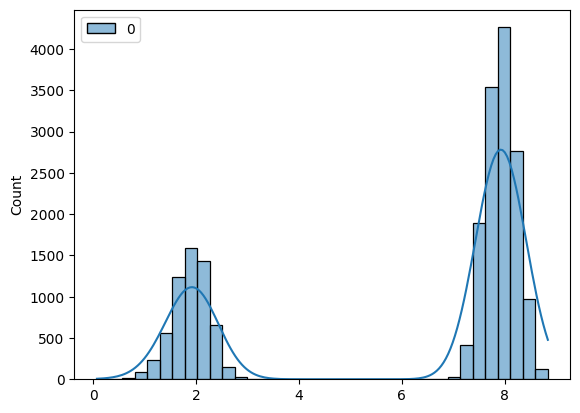

In [27]:
# observe posterior draws
sns.histplot(samples, kde=True,
             bins=int(180/5), color = 'blue')
plt.show()


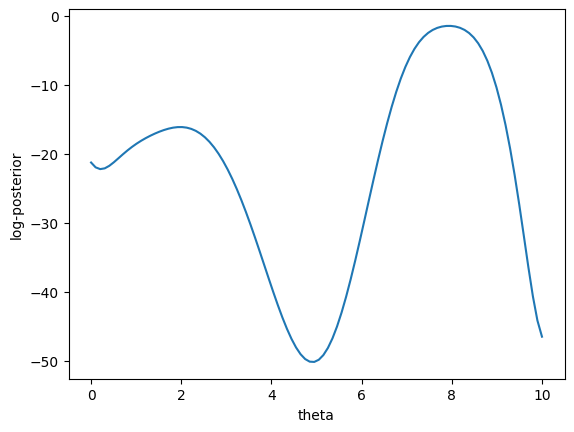

In [28]:
theta_vals = np.linspace(0, 10, 100)
logposts = [logposterior(t) for t in theta_vals]
plt.plot(theta_vals, logposts)
plt.xlabel("theta")
plt.ylabel("log-posterior")
plt.show()